In [1]:
import pandas as pd
df = pd.read_csv("../data/raw/raw.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          2500 non-null   int64  
 1   gender               2500 non-null   str    
 2   age                  2500 non-null   int64  
 3   region               2500 non-null   str    
 4   tenure_months        2500 non-null   int64  
 5   contract_type        2500 non-null   str    
 6   internet_service     2500 non-null   str    
 7   monthly_gb_download  2500 non-null   int64  
 8   streaming_package    2500 non-null   str    
 9   tech_support_calls   2444 non-null   float64
 10  payment_method       2480 non-null   str    
 11  monthly_charges      2500 non-null   float64
 12  total_charges        2500 non-null   float64
 13  late_payments        2500 non-null   int64  
 14  account_manager      2500 non-null   int64  
 15  last_login_date      2500 non-null   str    
 16 

In [2]:
df["customer_id"].nunique(), len(df)

(2500, 2500)

In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.isnull().sum().sort_values(ascending=False)

credit_score           250
tech_support_calls      56
payment_method          20
customer_id              0
gender                   0
age                      0
contract_type            0
internet_service         0
tenure_months            0
region                   0
streaming_package        0
monthly_gb_download      0
total_charges            0
monthly_charges          0
late_payments            0
account_manager          0
last_login_date          0
churn_label              0
dtype: int64

In [5]:
(df.isnull().mean() * 100).sort_values(ascending=False)

credit_score           10.00
tech_support_calls      2.24
payment_method          0.80
customer_id             0.00
gender                  0.00
age                     0.00
contract_type           0.00
internet_service        0.00
tenure_months           0.00
region                  0.00
streaming_package       0.00
monthly_gb_download     0.00
total_charges           0.00
monthly_charges         0.00
late_payments           0.00
account_manager         0.00
last_login_date         0.00
churn_label             0.00
dtype: float64

In [6]:
df.select_dtypes(include="object").nunique()

/tmp/ipykernel_65612/251659734.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").nunique()


gender                 5
region                 4
contract_type          3
internet_service       3
streaming_package      2
payment_method         4
last_login_date      367
dtype: int64

In [7]:
for col in df.select_dtypes(include="object").columns:
    print(col, df[col].unique()[:10])

gender <StringArray>
['Male', 'Female', 'm', 'male', 'MALE']
Length: 5, dtype: str
region <StringArray>
['South', 'East', 'North', 'West']
Length: 4, dtype: str
contract_type <StringArray>
['One year', 'Month-to-month', 'Two year']
Length: 3, dtype: str
internet_service <StringArray>
['Fiber optic', 'No', 'DSL']
Length: 3, dtype: str
streaming_package <StringArray>
['Yes', 'No']
Length: 2, dtype: str
payment_method <StringArray>
['Mailed check', 'Credit card', 'Electronic check', nan, 'Bank transfer']
Length: 5, dtype: str
last_login_date <StringArray>
['2023-11-24', '2023-02-27', '2023-01-13', '2023-05-21', '2023-05-06',
 '2023-04-25', '2023-03-13', '2023-02-22', '2023-12-13', '2023-10-07']
Length: 10, dtype: str


/tmp/ipykernel_65612/283005218.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [8]:
df.describe()

,customer_id,age,tenure_months,monthly_gb_download,tech_support_calls,monthly_charges,total_charges,late_payments,account_manager,credit_score,churn_label
count,2500.00000,2500.000000,2500.000000,2500.000000,2444.000000,2500.000000,2500.000000,2500.000000,2500.000000,2250.000000,2500.000000
mean,1250.50000,51.082400,20.282000,41.888800,0.974223,71.526900,1451.359704,0.492400,0.196800,571.425333,0.130000
std,721.83216,19.174949,25.358448,343.869634,0.978980,29.051013,1633.154161,0.701241,0.397659,155.107656,0.336371
min,1.00000,18.000000,1.000000,0.000000,0.000000,20.000000,20.000000,0.000000,0.000000,300.000000,0.000000
25%,625.75000,35.000000,6.000000,6.750000,0.000000,50.167500,362.967500,0.000000,0.000000,443.000000,0.000000
50%,1250.50000,51.000000,14.000000,23.000000,1.000000,71.155000,890.155000,0.000000,0.000000,565.500000,0.000000
75%,1875.25000,67.000000,27.000000,43.000000,2.000000,91.542500,1902.890000,1.000000,0.000000,702.000000,0.000000
max,2500.00000,84.000000,500.000000,9730.000000,7.000000,150.000000,15106.575000,4.000000,1.000000,849.000000,1.000000


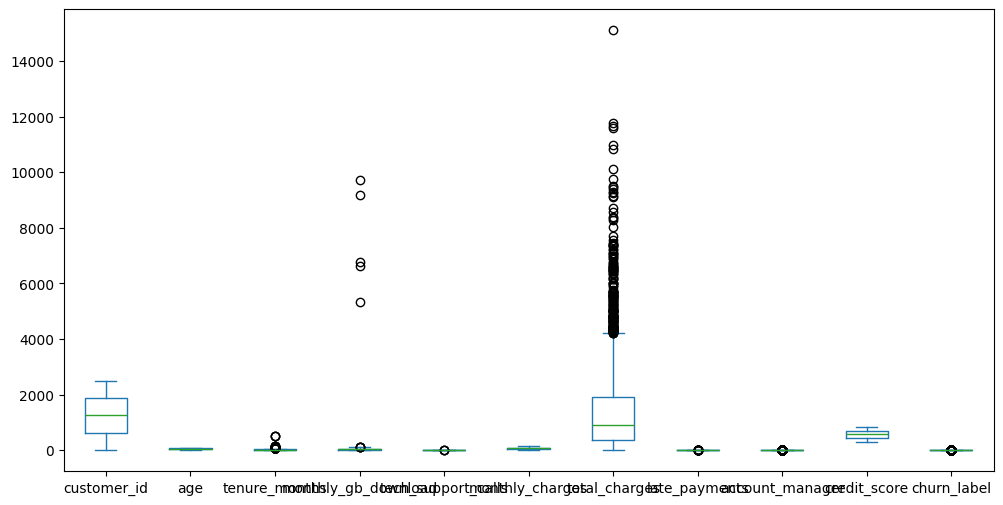

In [9]:
import matplotlib.pyplot as plt

df.select_dtypes(include="number").plot(kind="box", figsize=(12,6))
plt.show()

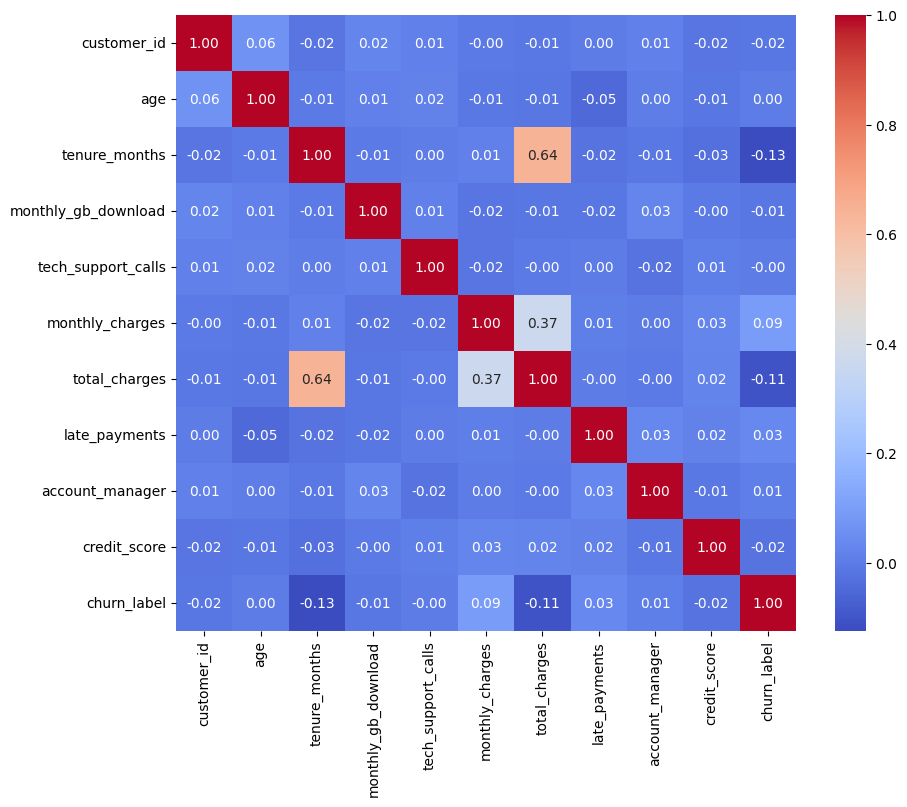

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [11]:
corr["churn_label"].sort_values(ascending=False)

churn_label            1.000000
monthly_charges        0.090336
late_payments          0.033879
account_manager        0.009094
age                    0.000076
tech_support_calls    -0.001424
monthly_gb_download   -0.013710
customer_id           -0.015186
credit_score          -0.021752
total_charges         -0.106618
tenure_months         -0.125100
Name: churn_label, dtype: float64

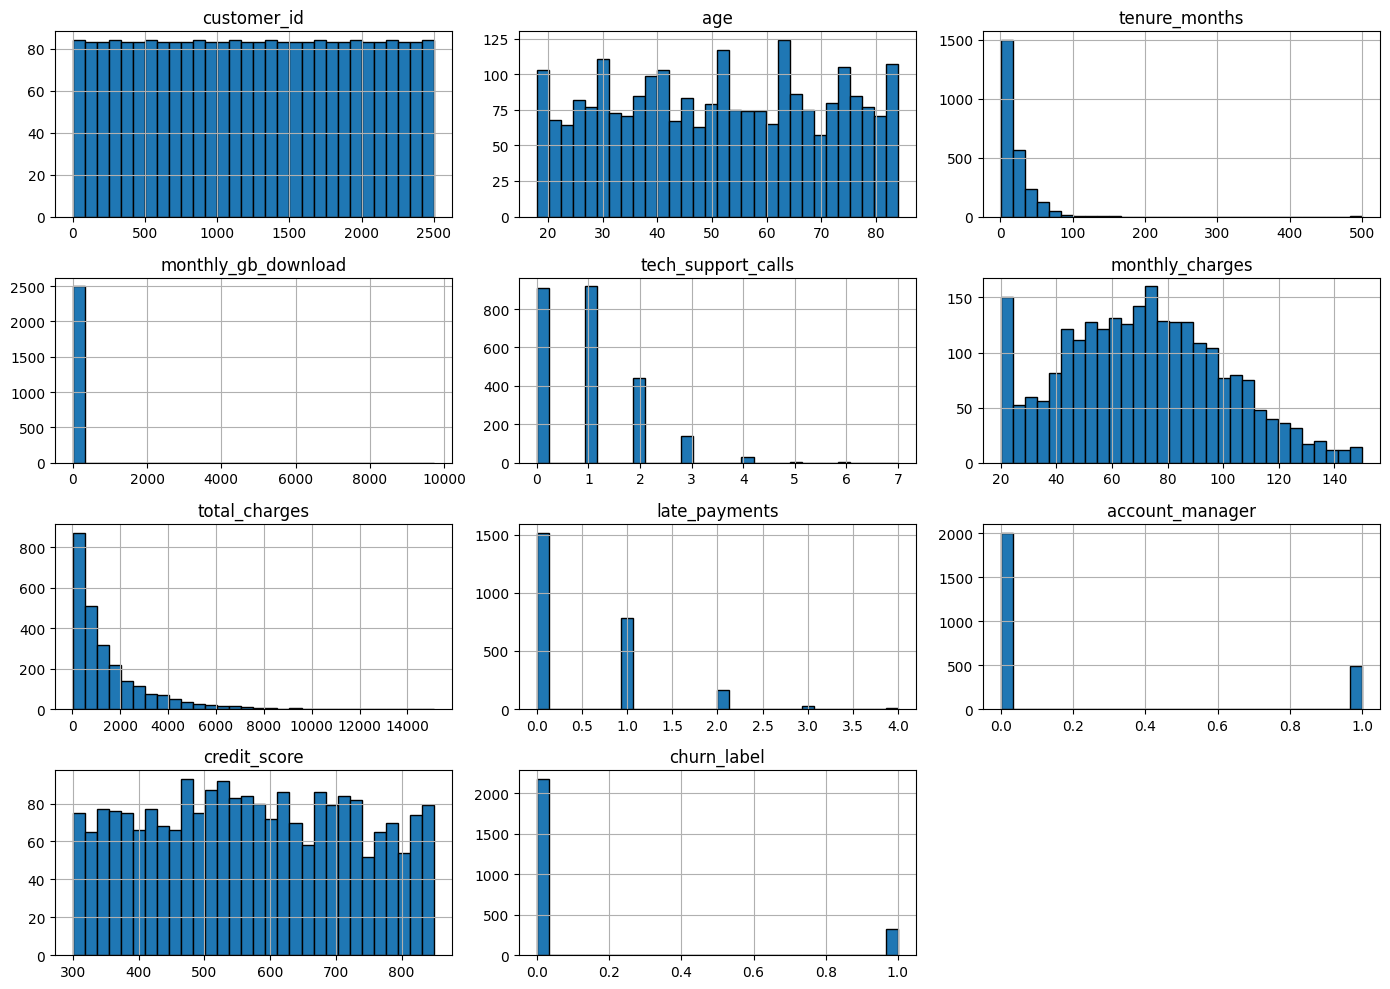

In [12]:
df.select_dtypes(include="number").hist(
    bins=30,
    figsize=(14,10),
    edgecolor="black"
)
plt.tight_layout()
plt.show()


In [13]:
df["churn_label"].value_counts()

churn_label
0    2175
1     325
Name: count, dtype: int64

In [14]:
df["churn_label"].value_counts(normalize=True) * 100

churn_label
0    87.0
1    13.0
Name: proportion, dtype: float64

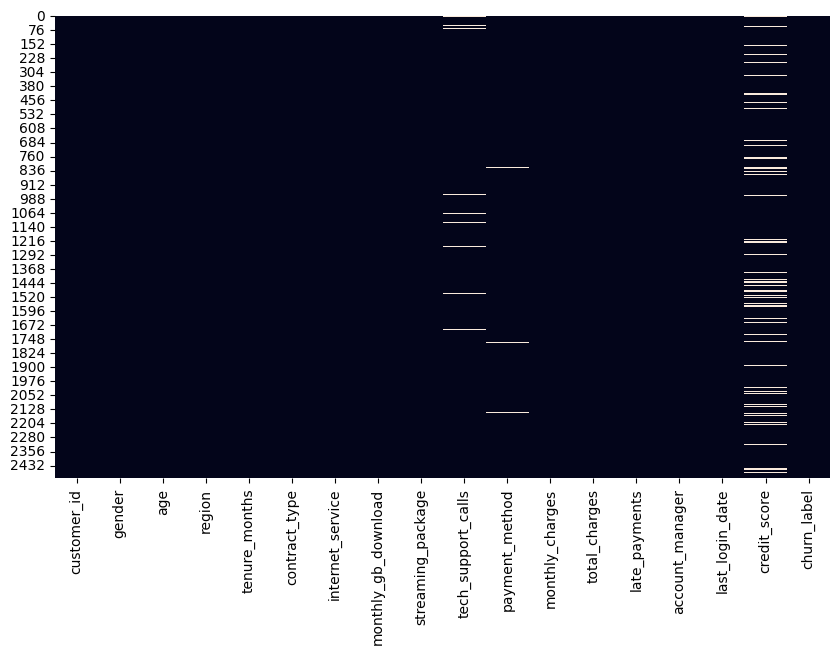

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.show()